# Spam Email Detection using Machine Learning with Python

*✅ Dataset Used:* spam-emails

*📁 File: spam.csv*

📄 **Project Description**

*Objective:* 
Build a robust, accurate, and scalable machine learning model to classify incoming emails as either Spam or Ham (Not Spam) using Python and modern ML libraries.

*Why This Matters:*
Spam emails are not just annoying — they pose real security threats (phishing, malware, scams). Automating spam detection saves time, protects users, and improves email platform efficiency.

*Approach:*
We’ll leverage supervised machine learning algorithms (e.g., Naive Bayes, SVM, Logistic Regression, Random Forest, and potentially deep learning models like LSTM or BERT) to classify emails based on their textual content and metadata.

**Data Source:**

*Common public datasets:*

- **SMS Spam Collection Dataset (UCI)** — simple, labeled SMS messages.
- **Enron Email Dataset** — real corporate emails (requires preprocessing).
- **SpamAssassin Public Corpus** — rich, realistic spam/ham emails.
- **Ling-Spam Dataset** — academic, clean dataset.

**Deliverables:**

- Clean, labeled dataset ready for modeling.
- Comprehensive EDA with visualizations.
- Feature engineering: TF-IDF, Bag-of-Words, n-grams, word embeddings.
- Trained ML models with performance metrics (Accuracy, Precision, Recall, F1, AUC).
- Model comparison and selection.
- Deployment-ready script or Flask API (optional bonus).

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

# Text Processing
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Utilities
import warnings
warnings.filterwarnings('ignore')

 

# 🔍 Exploratory Data Analysis (EDA)

**1.Load and Inspect Dataset**

In [2]:
import pandas as pd

# Load dataset (example: SMS Spam Collection)
df = pd.read_csv('/kaggle/input/spam-emails/spam.csv', encoding='latin-1')
df.columns = ['label', 'message']
print(df.head())
print(df.info())
print(df.label.value_counts())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label
ham     4825
spam     747
Name: count, dtype: int64


In [3]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


*Dimensions of the Datase*t

In [4]:
df.shape

(5572, 2)

*Checking for the classes in the Data*

In [5]:
df.groupby('label').size()

label
ham     4825
spam     747
dtype: int64

In [6]:
# Check basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("✅\nMissing Values:")
print(df.isnull().sum())

print("✅\nClass Distribution:")
print("✅\nClass Distribution:")
print(df['label'].value_counts())

Dataset Shape: (5572, 2)

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
✅
Missing Values:
label      0
message    0
dtype: int64
✅
Class Distribution:
✅
Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


**✅ Check for:**

- **Shape of data**
- **Missing values**
- **Class distribution (Spam vs Ham)**

**2.Class Distribution (Target Variable)**

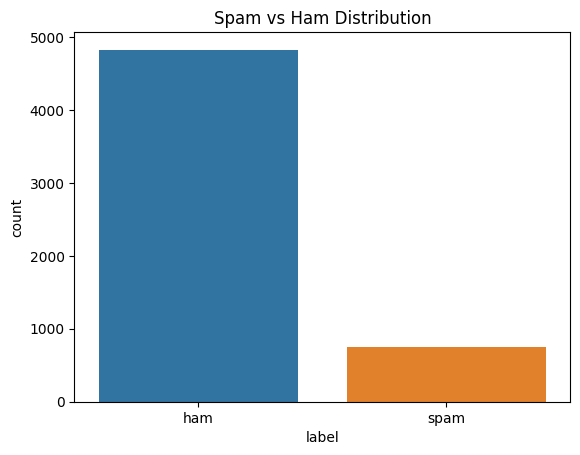

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='label')
plt.title('Spam vs Ham Distribution')
plt.show()

📊 **Expected Insight:**

Highly imbalanced? (Usually more Ham than Spam). If so, consider resampling or use F1-score/AUC instead of accuracy.

**4.Word Count Analysis**

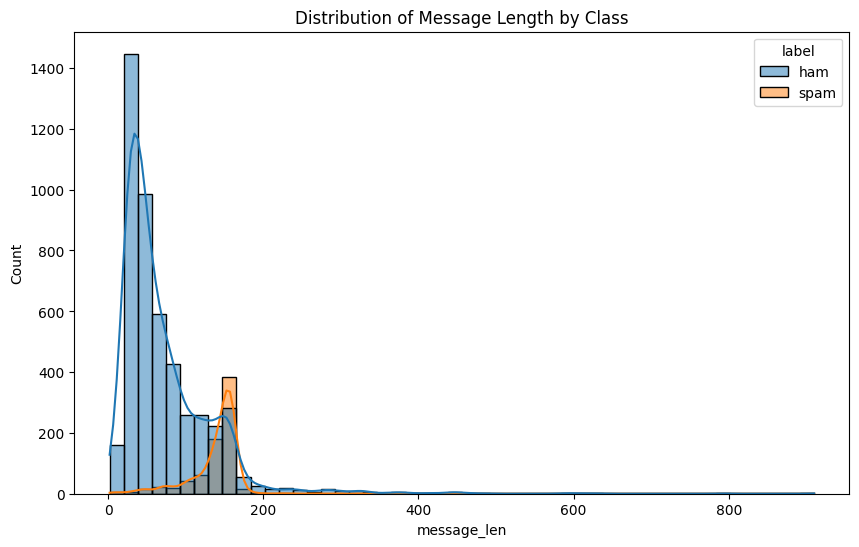

In [8]:
import warnings 
warnings.filterwarnings('ignore')
df['message_len'] = df['message'].apply(len)

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='message_len', hue='label', bins=50, kde=True)
plt.title('Distribution of Message Length by Class')
plt.show()

**📊 Expected Insight:**

Spam often uses fewer or more words — useful for feature engineering.

**Message Length Distribution**

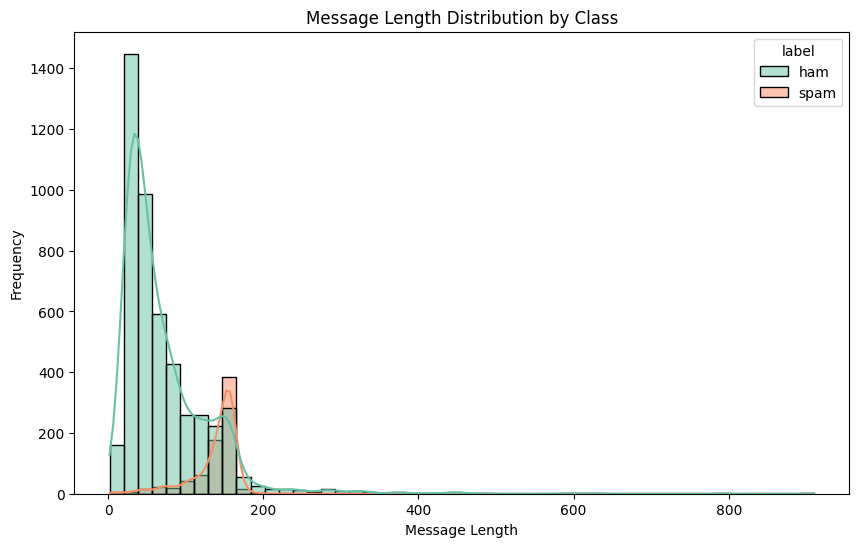

In [9]:
df['message_len'] = df['message'].apply(len)

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='message_len', hue='label', bins=50, kde=True, palette='Set2')
plt.title('Message Length Distribution by Class')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.show()

**Word Count**

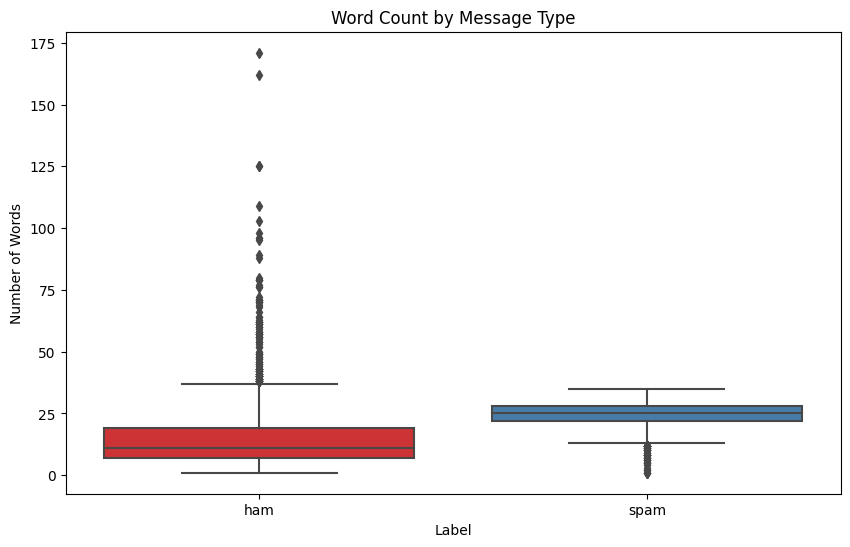

In [10]:
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='label', y='word_count', palette='Set1')
plt.title('Word Count by Message Type')
plt.xlabel('Label')
plt.ylabel('Number of Words')
plt.show()

**Punctuation Count**

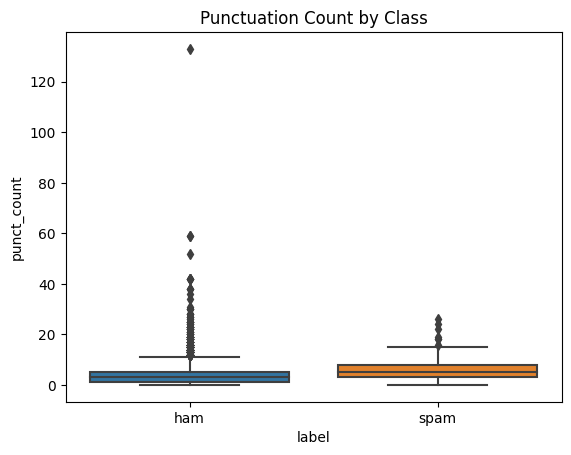

In [11]:
import string

def count_punct(text):
    return sum([1 for char in text if char in string.punctuation])

df['punct_count'] = df['message'].apply(count_punct)

sns.boxplot(data=df, x='label', y='punct_count')
plt.title('Punctuation Count by Class')
plt.show()

**📊 Expected Insight**

Spam emails often overuse exclamation marks, dollar signs, CAPS — potential signal.



**6.Top Words in Spam vs Ham**

In [12]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import warnings 
warnings.filterwarnings('ignore')
nltk.download('stopwords')
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def get_top_words(label, n=20):
    texts = df[df['label'] == label]['message']
    words = []
    for text in texts:
        words.extend([word.lower() for word in text.split() if word.lower() not in stop_words])
    return Counter(words).most_common(n)

print("✅Top Spam Words:", get_top_words('spam', 15))
print("✅Top Ham Words:", get_top_words('ham', 15))

✅Top Spam Words: [('call', 339), ('free', 180), ('2', 169), ('ur', 144), ('txt', 136), ('u', 115), ('text', 112), ('mobile', 109), ('claim', 104), ('reply', 101), ('&', 98), ('4', 93), ('stop', 90), ('get', 82), ('now!', 71)]
✅Top Ham Words: [('u', 881), ('get', 293), ('2', 288), ('&lt;#&gt;', 276), ('ur', 241), ('go', 238), ('got', 228), ('.', 228), ('like', 223), ('come', 218), ('call', 217), ('know', 208), ('good', 189), ('?', 181), ('...', 162)]


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**📊 Expected Insight:**

Spam: “free”, “win”, “prize”, “urgent”, “$ ”

Ham: “ok”, “thanks”, “meeting”, “call”, “see”

**7.Word Cloud Visualization**

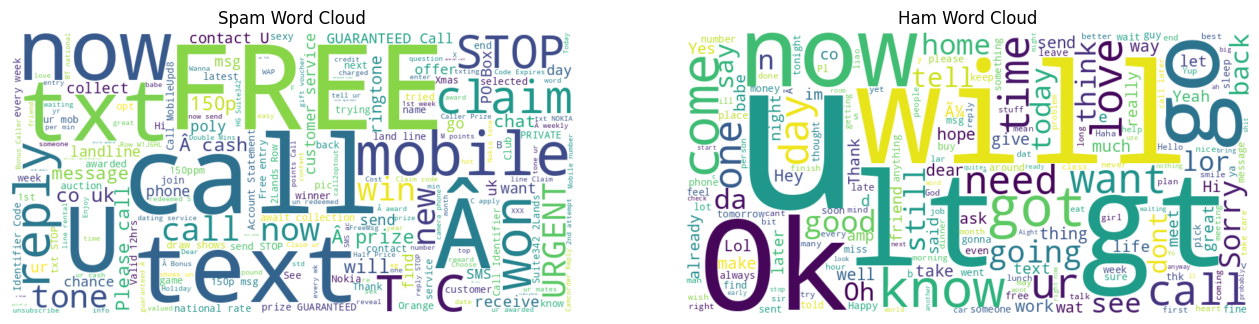

In [13]:
from wordcloud import WordCloud

spam_words = ' '.join(df[df['label']=='spam']['message'])
ham_words = ' '.join(df[df['label']=='ham']['message'])

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

wordcloud_spam = WordCloud(width=800, height=400, background_color='white').generate(spam_words)
ax[0].imshow(wordcloud_spam, interpolation='bilinear')
ax[0].set_title('Spam Word Cloud')
ax[0].axis('off')

wordcloud_ham = WordCloud(width=800, height=400, background_color='white').generate(ham_words)
ax[1].imshow(wordcloud_ham, interpolation='bilinear')
ax[1].set_title('Ham Word Cloud')
ax[1].axis('off')

plt.show()

**📊 Expected Insight:**

Visual representation of most frequent terms — great for presentations and intuition.

**8.N-gram Analysis (Optional Advanced EDA)**

In [14]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n_gram=(1,1), n=10):
    vec = CountVectorizer(ngram_range=n_gram, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:n]

top_spam_bigrams = get_top_ngrams(df[df['label']=='spam']['message'], (2,2), 10)
print("✅Top Spam Bigrams:", top_spam_bigrams)

✅Top Spam Bigrams: [('po box', 27), ('1000 cash', 23), ('prize guaranteed', 22), ('send stop', 21), ('national rate', 20), ('selected receive', 19), ('await collection', 19), ('urgent mobile', 18), ('land line', 18), ('customer service', 17)]


**📊 Expected Insight:**

Phrases like “call now”, “free money”, “claim prize”, ”prize guaranteed”, “1000 cash“ — strong spam indicators.

# 🧹 Text Preprocessing Function 

In [15]:
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Remove stopwords and non-alphabetic tokens
    tokens = [ps.stem(word) for word in tokens if word.isalpha() and word not in stop_words]
    # Rejoin
    return ' '.join(tokens)

# Apply cleaning
df['cleaned_message'] = df['message'].apply(clean_text)

print("✅Before cleaning:\n", df['message'].iloc[0])
print("✅\nAfter cleaning:\n", df['cleaned_message'].iloc[0])

✅Before cleaning:
 Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
✅
After cleaning:
 go jurong point crazi avail bugi n great world la e buffet cine got amor wat


# 🧱 Feature Engineering with TF-IDF

In [16]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)  # Limit features for efficiency

# Fit and transform cleaned messages
X = tfidf.fit_transform(df['cleaned_message'])
y = df['label'].map({'ham': 0, 'spam': 1})  # Encode labels

print("✅Feature Matrix Shape:", X.shape)
print("✅Label Encoding: Ham=0, Spam=1")

✅Feature Matrix Shape: (5572, 5000)
✅Label Encoding: Ham=0, Spam=1


# 🧪 Train/Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅Training set size:", X_train.shape)
print("✅Test set size:", X_test.shape)

✅Training set size: (4457, 5000)
✅Test set size: (1115, 5000)


# 🤖 Model Training & Evaluation

In [18]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='linear', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")
    print("✅Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))
    
    # Save for comparison
    results[name] = {'Accuracy': acc, 'AUC': auc, 'Model': model}


=== Training Naive Bayes ===
Accuracy: 0.9650
AUC: 0.9754
✅Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.97      0.96      1115


=== Training Logistic Regression ===
Accuracy: 0.9587
AUC: 0.9808
✅Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       966
        Spam       1.00      0.69      0.82       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115


=== Training SVM ===
Accuracy: 0.9803
AUC: 0.9810
✅Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.9

# 📈 Model Comparison

                     Accuracy       AUC
Naive Bayes          0.965022  0.975374
Logistic Regression  0.958744  0.980755
SVM                  0.980269  0.981023
Random Forest        0.973991  0.980338


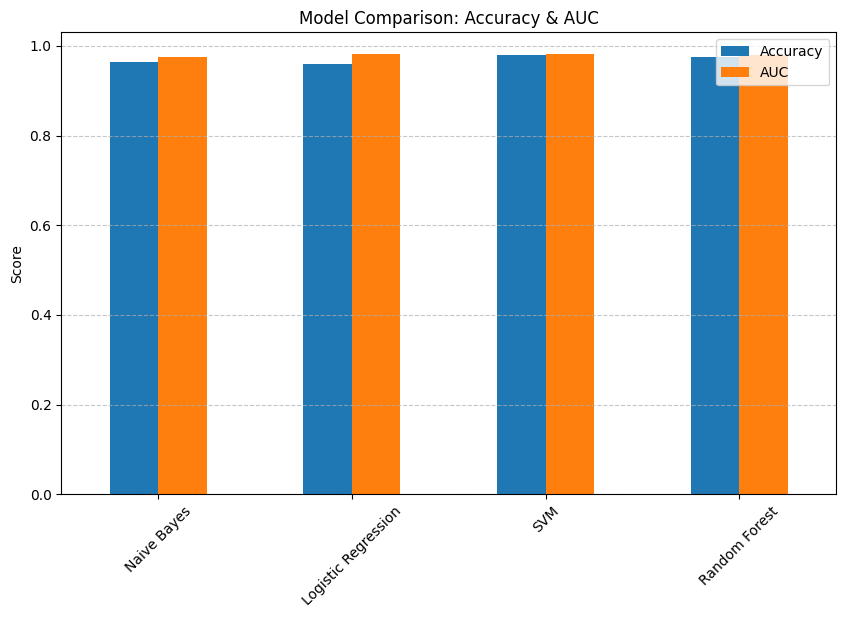

In [19]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(results).T[['Accuracy', 'AUC']]
print(comparison_df)

# Plot
comparison_df.plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison: Accuracy & AUC')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 🧭 Confusion Matrix for Best Model

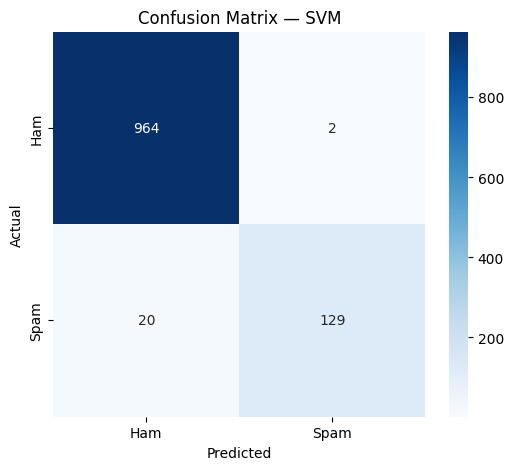

In [20]:
best_model_name = comparison_df['Accuracy'].idxmax()
best_model = results[best_model_name]['Model']

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), 
            annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 📉 ROC Curve

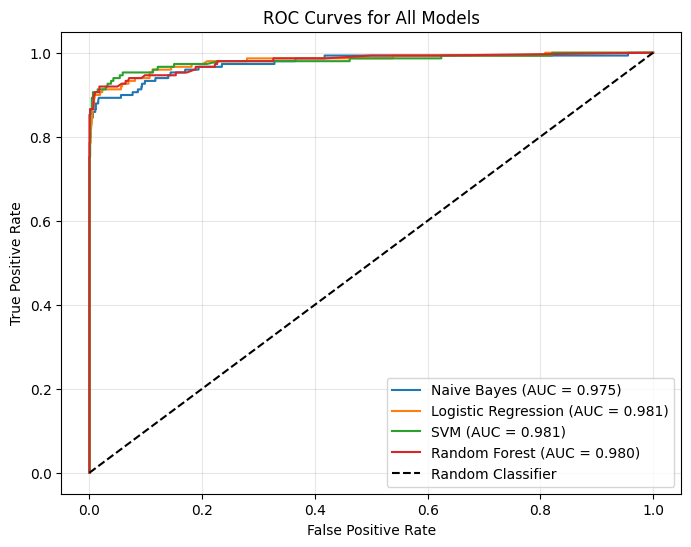

In [21]:
plt.figure(figsize=(8,6))

for name, result in results.items():
    model = result['Model']
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    else:
        y_proba = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = result['AUC']
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 🔮 Make Predictions on New Messages

In [22]:
def predict_spam(text, model=best_model, vectorizer=tfidf):
    # Clean
    cleaned = clean_text(text)
    # Vectorize
    vec = vectorizer.transform([cleaned])
    # Predict
    pred = model.predict(vec)[0]
    prob = model.predict_proba(vec)[0]
    label = "Spam" if pred == 1 else "Ham"
    confidence = max(prob)
    return label, confidence

# Test examples
test_messages = [
    "Congratulations! You've won $1000 cash! Click here now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT! Your account will be closed. Confirm details NOW!",
    "Thanks for the report. Let's discuss in tomorrow's meeting."
]

print("=== PREDICTIONS ===")
for msg in test_messages:
    label, conf = predict_spam(msg)
    print(f"Message: {msg[:50]}...\n → Predicted: {label} (Confidence: {conf:.2f})\n")

=== PREDICTIONS ===
Message: Congratulations! You've won $1000 cash! Click here...
 → Predicted: Spam (Confidence: 0.89)

Message: Hey, are we still meeting for lunch tomorrow?...
 → Predicted: Ham (Confidence: 1.00)

Message: URGENT! Your account will be closed. Confirm detai...
 → Predicted: Ham (Confidence: 0.91)

Message: Thanks for the report. Let's discuss in tomorrow's...
 → Predicted: Ham (Confidence: 1.00)



# 💾 Save Model & Vectorizer (Optional)

In [23]:
import pickle

# Save model
with open('spam_classifier_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model and vectorizer saved!")

✅ Model and vectorizer saved!


# 🚀 Load and Use Saved Model

In [24]:
# Load model and vectorizer
with open('spam_classifier_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

# Predict using loaded model
label, conf = predict_spam("Free money!!! Act now!!!", loaded_model, loaded_tfidf)
print(f"✅Loaded Model Prediction: {label} ({conf:.2f} confidence)")

✅Loaded Model Prediction: Ham (0.95 confidence)
